In [51]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal


load_dotenv()  # Load environment variables from .env file

True

In [52]:
# This is solution for sovling quadratic equations using conditional workflow


In [53]:
class EquationSchema(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result : str

In [54]:
def show_equation(state: EquationSchema):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {
        'equation': equation
    }

In [55]:
def calculate_discriminant(state: EquationSchema):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {
        'discriminant': discriminant
    }

In [56]:
def real_roots(state: EquationSchema):
    a = state['a']
    b = state['b']
    c = state['c']
    d = state['discriminant']
    root1 = (-b + d**0.5) / (2*a)
    root2 = (-b - d**0.5) / (2*a)
    return {
        'result': f"The roots are real and different: {root1} and {root2}"
    }

In [57]:
def repeated_roots(state: EquationSchema):
    a = state['a']
    b = state['b']
    root = -b / (2*a)
    return {
        'result': f"The roots are real and repeated: {root}"
    }

In [58]:
def no_real_roots(state: EquationSchema):
    return {
        'result': "The roots are complex and imaginary."
    }

In [59]:
def check_condition(state: EquationSchema) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    d = state['discriminant']
    if d > 0:
        return 'real_roots'
    elif d == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

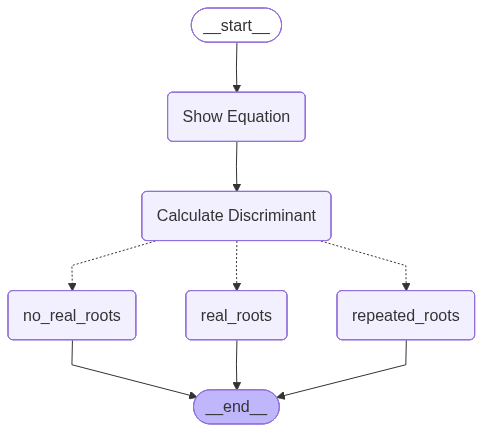

In [60]:
graph = StateGraph(EquationSchema)


graph.add_node("Show Equation", show_equation)
graph.add_node("Calculate Discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)


graph.add_edge(START, "Show Equation")
graph.add_edge("Show Equation", "Calculate Discriminant")

graph.add_conditional_edges("Calculate Discriminant", check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()
workflow


In [61]:
initial_state: EquationSchema = {
    'a': 1,
    'b': -3,
    'c': 2
    }

final_state = workflow.invoke(initial_state)

final_state

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'The roots are real and different: 2.0 and 1.0'}